In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tamarigelashvili/housing-pricess/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/datasets/tamarigelashvili/housing-pricess/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/datasets/tamarigelashvili/housing-pricess/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/datasets/tamarigelashvili/housing-pricess/house-prices-advanced-regression-techniques/test.csv


# SETUP

In [5]:
!pip install mlflow dagshub

In [6]:
import dagshub
dagshub.init(repo_owner='tgela23', repo_name='house-prices', mlflow=True)

import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=5aa8b3e4-4529-4146-83b8-52a8451dacf1&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=bcc18dece40e08099317e3dd46d32c7a92dda570a0657c6b8c8038389f7de89f




Output()

Accessing as tgela23

Initialized MLflow to track repo "tgela23/house-prices"

Repository tgela23/house-prices initialized!

🏃 View run shivering-mole-63 at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/50c533cd7e9e4f5e8ec71c5242c501e2
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0


In [7]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/tamarigelashvili/housing-pricess/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/datasets/tamarigelashvili/housing-pricess/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/datasets/tamarigelashvili/housing-pricess/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/datasets/tamarigelashvili/housing-pricess/house-prices-advanced-regression-techniques/test.csv


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

PATH = "/kaggle/input/datasets/tamarigelashvili/housing-pricess/house-prices-advanced-regression-techniques/"

train = pd.read_csv(PATH + "train.csv")
test = pd.read_csv(PATH + "test.csv")

X = train.drop(columns=["SalePrice"])
y = train["SalePrice"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (1168, 80)
X_test: (292, 80)


In [9]:
X_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal


# CLEANING

In [10]:
print("Id" in X_train.columns)

True


In [11]:
print(X_train["Id"].head(10))

254      255
1066    1067
638      639
799      800
380      381
303      304
86        87
1385    1386
265      266
793      794
Name: Id, dtype: int64


In [12]:
X_train = X_train.drop(columns="Id")

In [13]:
X_test = X_test.drop(columns="Id")

In [14]:
X_train.head()
X_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1066,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
638,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
799,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
380,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal


In [15]:
X_test.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
892,20,RL,70.0,8414,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,2,2006,WD,Normal
1105,60,RL,98.0,12256,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
413,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,3,2010,WD,Normal
522,50,RM,50.0,5000,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,10,2006,WD,Normal
1036,20,RL,89.0,12898,Pave,NaN,IR1,HLS,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2009,WD,Normal


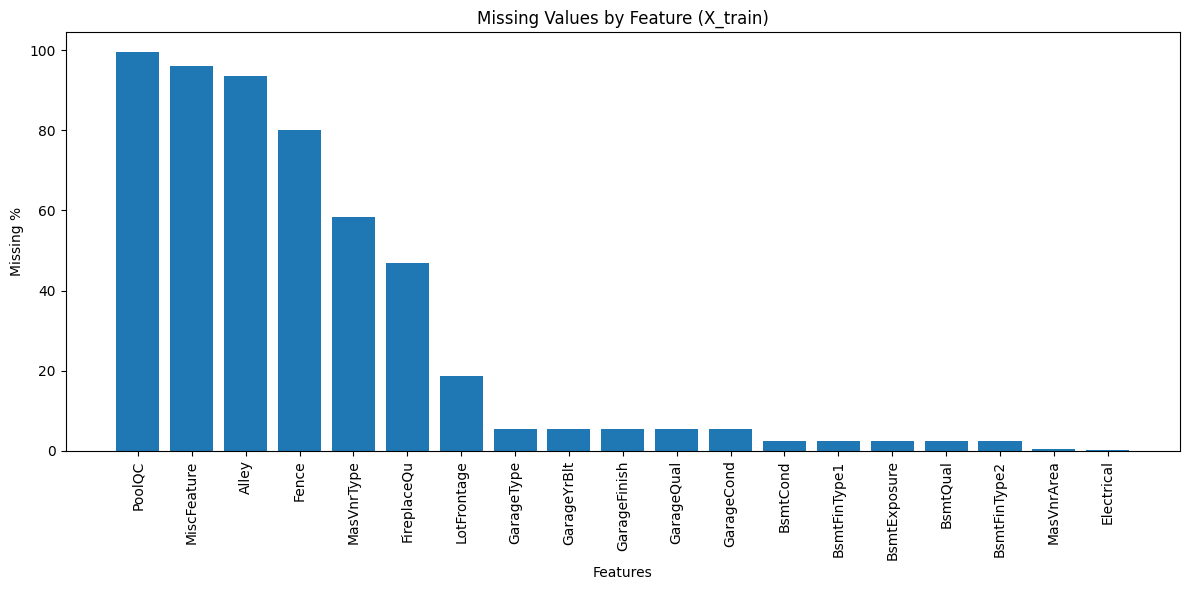

PoolQC          99.486301
MiscFeature     96.061644
Alley           93.664384
Fence           80.051370
MasVnrType      58.476027
FireplaceQu     46.832192
LotFrontage     18.578767
GarageType       5.479452
GarageYrBlt      5.479452
GarageFinish     5.479452
GarageQual       5.479452
GarageCond       5.479452
BsmtCond         2.397260
BsmtFinType1     2.397260
BsmtExposure     2.397260
BsmtQual         2.397260
BsmtFinType2     2.397260
MasVnrArea       0.513699
Electrical       0.085616
dtype: float64


In [16]:
import matplotlib.pyplot as plt

null_percent = X_train.isnull().sum() / len(X_train) * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(null_percent.index, null_percent.values)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Missing %")
plt.title("Missing Values by Feature (X_train)")
plt.tight_layout()
plt.show()

print(null_percent)


In [17]:
threshold = 80
cols_to_drop = null_percent[null_percent > threshold].index

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining {X_train.shape[1]} columns")

Dropped 4 columns: Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], dtype='object')
Remaining 75 columns


In [18]:
for col in X_train.columns:
    n_unique = X_train[col].nunique()
    top_val_pct = X_train[col].value_counts(normalize=True).iloc[0] * 100
    if top_val_pct > 90:
        print(f"{col}: {top_val_pct:.1f}% is '{X_train[col].value_counts().index[0]}' ({n_unique} unique values)")

Street: 99.7% is 'Pave' (2 unique values)
LandContour: 90.7% is 'Lvl' (4 unique values)
Utilities: 99.9% is 'AllPub' (2 unique values)
LandSlope: 94.9% is 'Gtl' (3 unique values)
Condition2: 99.1% is 'Norm' (8 unique values)
RoofMatl: 98.4% is 'CompShg' (7 unique values)
BsmtCond: 91.7% is 'TA' (4 unique values)
Heating: 97.6% is 'GasA' (6 unique values)
CentralAir: 92.9% is 'Y' (2 unique values)
Electrical: 91.8% is 'SBrkr' (4 unique values)
LowQualFinSF: 98.2% is '0' (20 unique values)
BsmtHalfBath: 94.3% is '0' (3 unique values)
KitchenAbvGr: 95.2% is '1' (4 unique values)
Functional: 92.8% is 'Typ' (7 unique values)
GarageQual: 95.1% is 'TA' (5 unique values)
GarageCond: 96.1% is 'TA' (5 unique values)
PavedDrive: 91.6% is 'Y' (3 unique values)
3SsnPorch: 98.3% is '0' (17 unique values)
ScreenPorch: 91.7% is '0' (66 unique values)
PoolArea: 99.5% is '0' (7 unique values)
MiscVal: 96.2% is '0' (19 unique values)


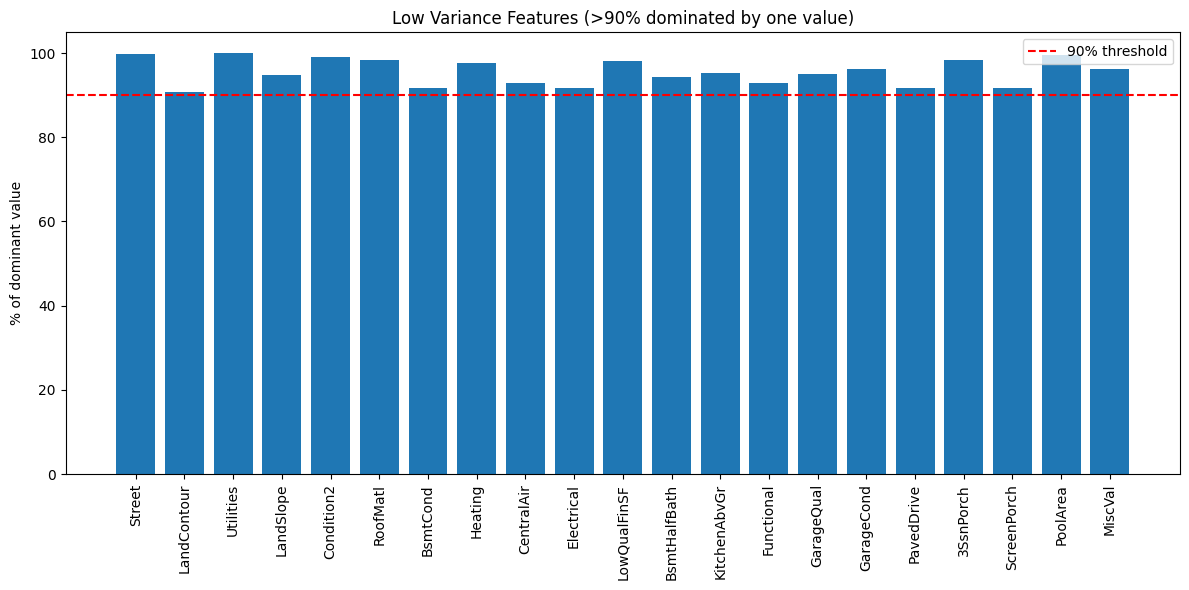

Found 21 low variance columns: ['Street', 'LandContour', 'Utilities', 'LandSlope', 'Condition2', 'RoofMatl', 'BsmtCond', 'Heating', 'CentralAir', 'Electrical', 'LowQualFinSF', 'BsmtHalfBath', 'KitchenAbvGr', 'Functional', 'GarageQual', 'GarageCond', 'PavedDrive', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']


In [19]:
import matplotlib.pyplot as plt

low_var_cols = []
low_var_pcts = []

for col in X_train.columns:
    top_val_pct = X_train[col].value_counts(normalize=True).iloc[0] * 100
    if top_val_pct > 90:
        low_var_cols.append(col)
        low_var_pcts.append(top_val_pct)

plt.figure(figsize=(12, 6))
plt.bar(low_var_cols, low_var_pcts)
plt.axhline(y=90, color='r', linestyle='--', label='90% threshold')
plt.xticks(rotation=90)
plt.ylabel("% of dominant value")
plt.title("Low Variance Features (>90% dominated by one value)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Found {len(low_var_cols)} low variance columns: {low_var_cols}")

In [20]:
cols_to_drop = ["LowQualFinSF", "BsmtHalfBath", "MiscVal", "KitchenAbvGr", "3SsnPorch", "ScreenPorch"]

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"dropped columns: {cols_to_drop}")
print(f"remaining {X_train.shape[1]} columns in train")
print(f"remaining {X_test.shape[1]} columns in test")

dropped columns: ['LowQualFinSF', 'BsmtHalfBath', 'MiscVal', 'KitchenAbvGr', '3SsnPorch', 'ScreenPorch']
remaining 69 columns in train
remaining 69 columns in test


In [21]:
(X_train["TotalBsmtSF"] == 
 (X_train["BsmtFinSF1"] + X_train["BsmtFinSF2"] + X_train["BsmtUnfSF"])
).all()

np.True_

In [22]:
cols_to_drop = ["BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF"]

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"dropped columns: {cols_to_drop}")
print(f"remaining {X_train.shape[1]} columns in train")
print(f"remaining {X_test.shape[1]} columns in test")

dropped columns: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']
remaining 66 columns in train
remaining 66 columns in test


In [23]:
X_train = X_train.drop(columns=["GarageArea"])
X_test = X_test.drop(columns=["GarageArea"])

print(f"dropped columns: {cols_to_drop}")
print(f"remaining {X_train.shape[1]} columns in train")
print(f"remaining {X_test.shape[1]} columns in test")

dropped columns: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']
remaining 65 columns in train
remaining 65 columns in test


In [24]:
null_cols = X_train.isnull().sum()
null_cols = null_cols[null_cols > 0].sort_values(ascending=False)
print(null_cols)

MasVnrType      683
FireplaceQu     547
LotFrontage     217
GarageYrBlt      64
GarageFinish     64
GarageType       64
GarageQual       64
GarageCond       64
BsmtQual         28
BsmtCond         28
BsmtExposure     28
BsmtFinType2     28
BsmtFinType1     28
MasVnrArea        6
Electrical        1
dtype: int64


In [25]:
(X_train["GarageCond"] == X_train["GarageQual"]).all()

np.False_

In [26]:
match_ratio = (
    X_train["GarageCond"].fillna("NA") ==
    X_train["GarageQual"].fillna("NA")
).mean()

print(match_ratio)

0.9606164383561644


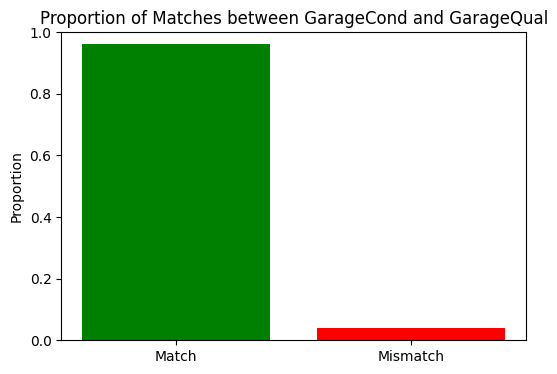

In [27]:
import matplotlib.pyplot as plt

match_ratio = (X_train["GarageCond"].fillna("NA") == X_train["GarageQual"].fillna("NA")).mean()

labels = ['Match', 'Mismatch']
values = [match_ratio, 1 - match_ratio]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['green', 'red'])
plt.title('Proportion of Matches between GarageCond and GarageQual')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.show()

In [28]:
X_train = X_train.drop(columns=['GarageCond'])
X_test = X_test.drop(columns=['GarageCond'])

In [29]:
print(f"remaining {X_train.shape[1]} columns in train")
print(f"remaining {X_test.shape[1]} columns in test")

remaining 64 columns in train
remaining 64 columns in test


In [30]:
match_ratio = (
    X_train["ExterQual"].fillna("NA") ==
    X_train["ExterCond"].fillna("NA")
).mean()

print(match_ratio)

0.5547945205479452


In [31]:
match_ratio = (
    X_train["BsmtQual"].fillna("NA") ==
    X_train["BsmtCond"].fillna("NA")
).mean()

print(match_ratio)

0.4666095890410959


In [32]:
print(f"remaining columns = {X_train.info()}")

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 64 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1168 non-null   int64  
 1   MSZoning       1168 non-null   object 
 2   LotFrontage    951 non-null    float64
 3   LotArea        1168 non-null   int64  
 4   Street         1168 non-null   object 
 5   LotShape       1168 non-null   object 
 6   LandContour    1168 non-null   object 
 7   Utilities      1168 non-null   object 
 8   LotConfig      1168 non-null   object 
 9   LandSlope      1168 non-null   object 
 10  Neighborhood   1168 non-null   object 
 11  Condition1     1168 non-null   object 
 12  Condition2     1168 non-null   object 
 13  BldgType       1168 non-null   object 
 14  HouseStyle     1168 non-null   object 
 15  OverallQual    1168 non-null   int64  
 16  OverallCond    1168 non-null   int64  
 17  YearBuilt      1168 non-null   int64  
 18  YearRemodAd

In [33]:
match_ratio = (
    X_train["OverallQual"].fillna("NA") ==
    X_train["OverallCond"].fillna("NA")
).mean()

print(match_ratio)

0.1892123287671233


In [34]:
cols_to_drop = ['Utilities', 'Street', 'PoolArea', 'Condition2', 'RoofMatl', 'Heating']

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"dropped columns: {cols_to_drop}")
print(f"remaining {X_train.shape[1]} columns in train")
print(f"remaining {X_test.shape[1]} columns in test")

dropped columns: ['Utilities', 'Street', 'PoolArea', 'Condition2', 'RoofMatl', 'Heating']
remaining 58 columns in train
remaining 58 columns in test


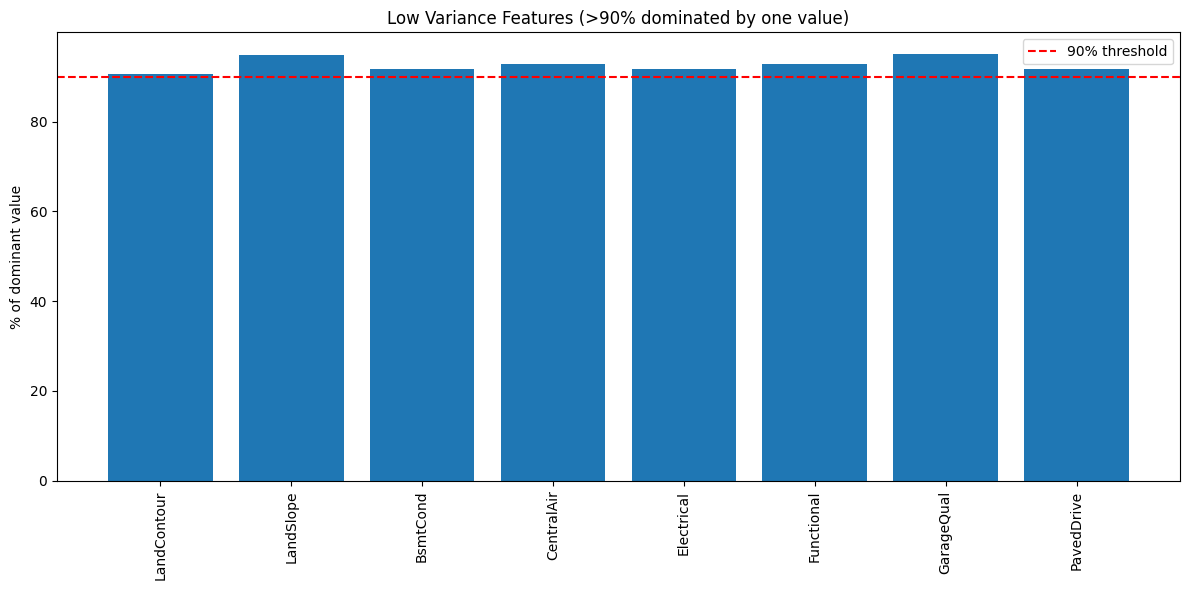

Found 8 low variance columns: ['LandContour', 'LandSlope', 'BsmtCond', 'CentralAir', 'Electrical', 'Functional', 'GarageQual', 'PavedDrive']


In [35]:
import matplotlib.pyplot as plt

low_var_cols = []
low_var_pcts = []

for col in X_train.columns:
    top_val_pct = X_train[col].value_counts(normalize=True).iloc[0] * 100
    if top_val_pct > 90:
        low_var_cols.append(col)
        low_var_pcts.append(top_val_pct)

plt.figure(figsize=(12, 6))
plt.bar(low_var_cols, low_var_pcts)
plt.axhline(y=90, color='r', linestyle='--', label='90% threshold')
plt.xticks(rotation=90)
plt.ylabel("% of dominant value")
plt.title("Low Variance Features (>90% dominated by one value)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Found {len(low_var_cols)} low variance columns: {low_var_cols}")

In [36]:
X_train = X_train.drop(columns="LandSlope")
X_test = X_test.drop(columns="LandSlope")

In [37]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 57 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1168 non-null   int64  
 1   MSZoning       1168 non-null   object 
 2   LotFrontage    951 non-null    float64
 3   LotArea        1168 non-null   int64  
 4   LotShape       1168 non-null   object 
 5   LandContour    1168 non-null   object 
 6   LotConfig      1168 non-null   object 
 7   Neighborhood   1168 non-null   object 
 8   Condition1     1168 non-null   object 
 9   BldgType       1168 non-null   object 
 10  HouseStyle     1168 non-null   object 
 11  OverallQual    1168 non-null   int64  
 12  OverallCond    1168 non-null   int64  
 13  YearBuilt      1168 non-null   int64  
 14  YearRemodAdd   1168 non-null   int64  
 15  RoofStyle      1168 non-null   object 
 16  Exterior1st    1168 non-null   object 
 17  Exterior2nd    1168 non-null   object 
 18  MasVnrType 

In [38]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292 entries, 892 to 722
Data columns (total 57 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     292 non-null    int64  
 1   MSZoning       292 non-null    object 
 2   LotFrontage    250 non-null    float64
 3   LotArea        292 non-null    int64  
 4   LotShape       292 non-null    object 
 5   LandContour    292 non-null    object 
 6   LotConfig      292 non-null    object 
 7   Neighborhood   292 non-null    object 
 8   Condition1     292 non-null    object 
 9   BldgType       292 non-null    object 
 10  HouseStyle     292 non-null    object 
 11  OverallQual    292 non-null    int64  
 12  OverallCond    292 non-null    int64  
 13  YearBuilt      292 non-null    int64  
 14  YearRemodAdd   292 non-null    int64  
 15  RoofStyle      292 non-null    object 
 16  Exterior1st    292 non-null    object 
 17  Exterior2nd    292 non-null    object 
 18  MasVnrType   

In [39]:
X_train.drop(columns="FireplaceQu")
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 57 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1168 non-null   int64  
 1   MSZoning       1168 non-null   object 
 2   LotFrontage    951 non-null    float64
 3   LotArea        1168 non-null   int64  
 4   LotShape       1168 non-null   object 
 5   LandContour    1168 non-null   object 
 6   LotConfig      1168 non-null   object 
 7   Neighborhood   1168 non-null   object 
 8   Condition1     1168 non-null   object 
 9   BldgType       1168 non-null   object 
 10  HouseStyle     1168 non-null   object 
 11  OverallQual    1168 non-null   int64  
 12  OverallCond    1168 non-null   int64  
 13  YearBuilt      1168 non-null   int64  
 14  YearRemodAdd   1168 non-null   int64  
 15  RoofStyle      1168 non-null   object 
 16  Exterior1st    1168 non-null   object 
 17  Exterior2nd    1168 non-null   object 
 18  MasVnrType 

In [40]:
X_test.drop(columns="FireplaceQu")

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,Neighborhood,Condition1,BldgType,...,GarageCars,GarageQual,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,MoSold,YrSold,SaleType,SaleCondition
892,20,RL,70.0,8414,Reg,Lvl,Inside,Sawyer,Norm,1Fam,...,1,TA,Y,192,0,0,2,2006,WD,Normal
1105,60,RL,98.0,12256,IR1,Lvl,Corner,NoRidge,Norm,1Fam,...,2,TA,Y,186,32,0,4,2010,WD,Normal
413,30,RM,56.0,8960,Reg,Lvl,Inside,OldTown,Artery,1Fam,...,2,TA,Y,0,0,130,3,2010,WD,Normal
522,50,RM,50.0,5000,Reg,Lvl,Corner,BrkSide,Feedr,1Fam,...,2,TA,Y,0,24,36,10,2006,WD,Normal
1036,20,RL,89.0,12898,IR1,HLS,Inside,Timber,Norm,1Fam,...,3,TA,Y,228,0,0,9,2009,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,30,RM,50.0,5925,Reg,Bnk,Inside,OldTown,Norm,1Fam,...,2,TA,Y,0,72,0,3,2007,WD,Alloca
1361,20,RL,124.0,16158,IR1,Low,Inside,StoneBr,Norm,1Fam,...,2,TA,Y,168,36,0,6,2009,WD,Normal
802,60,RL,63.0,8199,Reg,Lvl,Inside,CollgCr,Norm,1Fam,...,2,TA,Y,36,18,0,10,2008,WD,Normal
651,70,RL,60.0,9084,Reg,Lvl,Inside,Edwards,Artery,1Fam,...,1,Fa,P,120,0,0,10,2009,WD,Normal


In [41]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292 entries, 892 to 722
Data columns (total 57 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     292 non-null    int64  
 1   MSZoning       292 non-null    object 
 2   LotFrontage    250 non-null    float64
 3   LotArea        292 non-null    int64  
 4   LotShape       292 non-null    object 
 5   LandContour    292 non-null    object 
 6   LotConfig      292 non-null    object 
 7   Neighborhood   292 non-null    object 
 8   Condition1     292 non-null    object 
 9   BldgType       292 non-null    object 
 10  HouseStyle     292 non-null    object 
 11  OverallQual    292 non-null    int64  
 12  OverallCond    292 non-null    int64  
 13  YearBuilt      292 non-null    int64  
 14  YearRemodAdd   292 non-null    int64  
 15  RoofStyle      292 non-null    object 
 16  Exterior1st    292 non-null    object 
 17  Exterior2nd    292 non-null    object 
 18  MasVnrType   

In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 57 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1168 non-null   int64  
 1   MSZoning       1168 non-null   object 
 2   LotFrontage    951 non-null    float64
 3   LotArea        1168 non-null   int64  
 4   LotShape       1168 non-null   object 
 5   LandContour    1168 non-null   object 
 6   LotConfig      1168 non-null   object 
 7   Neighborhood   1168 non-null   object 
 8   Condition1     1168 non-null   object 
 9   BldgType       1168 non-null   object 
 10  HouseStyle     1168 non-null   object 
 11  OverallQual    1168 non-null   int64  
 12  OverallCond    1168 non-null   int64  
 13  YearBuilt      1168 non-null   int64  
 14  YearRemodAdd   1168 non-null   int64  
 15  RoofStyle      1168 non-null   object 
 16  Exterior1st    1168 non-null   object 
 17  Exterior2nd    1168 non-null   object 
 18  MasVnrType 

In [43]:
match_ratio = (
    X_train["YearBuilt"].fillna("NA") ==
    X_train["GarageYrBlt"].fillna("NA")
).mean()

print(match_ratio)

0.738013698630137


In [44]:
X_train = X_train.drop(columns="GarageYrBlt")
X_test = X_test.drop(columns="GarageYrBlt")

In [45]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 56 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1168 non-null   int64  
 1   MSZoning       1168 non-null   object 
 2   LotFrontage    951 non-null    float64
 3   LotArea        1168 non-null   int64  
 4   LotShape       1168 non-null   object 
 5   LandContour    1168 non-null   object 
 6   LotConfig      1168 non-null   object 
 7   Neighborhood   1168 non-null   object 
 8   Condition1     1168 non-null   object 
 9   BldgType       1168 non-null   object 
 10  HouseStyle     1168 non-null   object 
 11  OverallQual    1168 non-null   int64  
 12  OverallCond    1168 non-null   int64  
 13  YearBuilt      1168 non-null   int64  
 14  YearRemodAdd   1168 non-null   int64  
 15  RoofStyle      1168 non-null   object 
 16  Exterior1st    1168 non-null   object 
 17  Exterior2nd    1168 non-null   object 
 18  MasVnrType 

In [46]:
match_ratio = (
    X_train["BsmtFinType1"].fillna("NA") ==
    X_train["BsmtFinType2"].fillna("NA")
).mean()

print(match_ratio)

0.3193493150684932


# FEATURE ENGINEERING

In [47]:
X_train['MoSold'] = X_train['MoSold'].astype(str)

In [48]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 56 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1168 non-null   int64  
 1   MSZoning       1168 non-null   object 
 2   LotFrontage    951 non-null    float64
 3   LotArea        1168 non-null   int64  
 4   LotShape       1168 non-null   object 
 5   LandContour    1168 non-null   object 
 6   LotConfig      1168 non-null   object 
 7   Neighborhood   1168 non-null   object 
 8   Condition1     1168 non-null   object 
 9   BldgType       1168 non-null   object 
 10  HouseStyle     1168 non-null   object 
 11  OverallQual    1168 non-null   int64  
 12  OverallCond    1168 non-null   int64  
 13  YearBuilt      1168 non-null   int64  
 14  YearRemodAdd   1168 non-null   int64  
 15  RoofStyle      1168 non-null   object 
 16  Exterior1st    1168 non-null   object 
 17  Exterior2nd    1168 non-null   object 
 18  MasVnrType 

In [49]:
X_test['MoSold'] = X_test['MoSold'].astype(str)

In [50]:
X_train['HouseAge'] = X_train['YrSold'] - X_train['YearBuilt']
X_test['HouseAge'] = X_test['YrSold'] - X_test['YearBuilt']

In [51]:
X_train['YearsSinceRemod'] = X_train['YrSold'] - X_train['YearRemodAdd']
X_test['YearsSinceRemod'] = X_test['YrSold'] - X_test['YearRemodAdd']

In [52]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MSSubClass       1168 non-null   int64  
 1   MSZoning         1168 non-null   object 
 2   LotFrontage      951 non-null    float64
 3   LotArea          1168 non-null   int64  
 4   LotShape         1168 non-null   object 
 5   LandContour      1168 non-null   object 
 6   LotConfig        1168 non-null   object 
 7   Neighborhood     1168 non-null   object 
 8   Condition1       1168 non-null   object 
 9   BldgType         1168 non-null   object 
 10  HouseStyle       1168 non-null   object 
 11  OverallQual      1168 non-null   int64  
 12  OverallCond      1168 non-null   int64  
 13  YearBuilt        1168 non-null   int64  
 14  YearRemodAdd     1168 non-null   int64  
 15  RoofStyle        1168 non-null   object 
 16  Exterior1st      1168 non-null   object 
 17  Exterior2nd      

In [53]:
cols_to_drop = ["YearBuilt", "YearRemodAdd", "YrSold"]

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"dropped columns: {cols_to_drop}")
print(f"remaining {X_train.shape[1]} columns in train")
print(f"remaining {X_test.shape[1]} columns in test")

dropped columns: ['YearBuilt', 'YearRemodAdd', 'YrSold']
remaining 55 columns in train
remaining 55 columns in test


In [54]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 55 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MSSubClass       1168 non-null   int64  
 1   MSZoning         1168 non-null   object 
 2   LotFrontage      951 non-null    float64
 3   LotArea          1168 non-null   int64  
 4   LotShape         1168 non-null   object 
 5   LandContour      1168 non-null   object 
 6   LotConfig        1168 non-null   object 
 7   Neighborhood     1168 non-null   object 
 8   Condition1       1168 non-null   object 
 9   BldgType         1168 non-null   object 
 10  HouseStyle       1168 non-null   object 
 11  OverallQual      1168 non-null   int64  
 12  OverallCond      1168 non-null   int64  
 13  RoofStyle        1168 non-null   object 
 14  Exterior1st      1168 non-null   object 
 15  Exterior2nd      1168 non-null   object 
 16  MasVnrType       485 non-null    object 
 17  MasVnrArea       

In [55]:
X_train['Has2ndFlr'] = (X_train['2ndFlrSF'] > 0).astype(int)
X_test['Has2ndFlr'] = (X_test['2ndFlrSF'] > 0).astype(int)

In [56]:
X_train = X_train.drop(columns="Has2ndFlr")
X_test = X_test.drop(columns="Has2ndFlr")

In [57]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 55 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MSSubClass       1168 non-null   int64  
 1   MSZoning         1168 non-null   object 
 2   LotFrontage      951 non-null    float64
 3   LotArea          1168 non-null   int64  
 4   LotShape         1168 non-null   object 
 5   LandContour      1168 non-null   object 
 6   LotConfig        1168 non-null   object 
 7   Neighborhood     1168 non-null   object 
 8   Condition1       1168 non-null   object 
 9   BldgType         1168 non-null   object 
 10  HouseStyle       1168 non-null   object 
 11  OverallQual      1168 non-null   int64  
 12  OverallCond      1168 non-null   int64  
 13  RoofStyle        1168 non-null   object 
 14  Exterior1st      1168 non-null   object 
 15  Exterior2nd      1168 non-null   object 
 16  MasVnrType       485 non-null    object 
 17  MasVnrArea       

In [58]:
match_ratio = (
    X_train["TotalBsmtSF"].fillna("NA") ==
    X_train["1stFlrSF"].fillna("NA")
).mean()

print(match_ratio)

0.502568493150685


In [59]:
int_cols = X_train.select_dtypes(include='int64').columns
print(int_cols)

Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'TotalBsmtSF',
       '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'HouseAge',
       'YearsSinceRemod'],
      dtype='object')


In [60]:
X_train['Has2ndFlr'] = (X_train['2ndFlrSF'] > 0).astype(int)
X_test['Has2ndFlr'] = (X_test['2ndFlrSF'] > 0).astype(int)

In [61]:
X_train = X_train.drop(columns="2ndFlrSF")
X_test = X_test.drop(columns="2ndFlrSF")

In [62]:
int_cols = X_train.select_dtypes(include='int64').columns
print(int_cols)

Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'TotalBsmtSF',
       '1stFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'HouseAge',
       'YearsSinceRemod', 'Has2ndFlr'],
      dtype='object')


In [63]:
cat_cols = X_train.select_dtypes(include='object').columns
print(cat_cols)

Index(['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'Neighborhood',
       'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'PavedDrive',
       'MoSold', 'SaleType', 'SaleCondition'],
      dtype='object')


In [64]:
object_cols = X_train.select_dtypes(include=['object']).columns
cardinality = X_train[object_cols].nunique().sort_values(ascending=False)
print(cardinality)

Neighborhood     25
Exterior2nd      16
Exterior1st      15
MoSold           12
SaleType          9
Condition1        9
HouseStyle        8
Functional        7
BsmtFinType1      6
RoofStyle         6
BsmtFinType2      6
GarageType        6
SaleCondition     6
Foundation        6
MSZoning          5
BldgType          5
LotConfig         5
FireplaceQu       5
GarageQual        5
ExterCond         5
HeatingQC         5
LotShape          4
LandContour       4
ExterQual         4
BsmtQual          4
KitchenQual       4
BsmtCond          4
Electrical        4
BsmtExposure      4
MasVnrType        3
GarageFinish      3
PavedDrive        3
CentralAir        2
dtype: int64


In [65]:
X_train = X_train.drop(columns="Exterior2nd")
X_test = X_test.drop(columns="Exterior2nd")

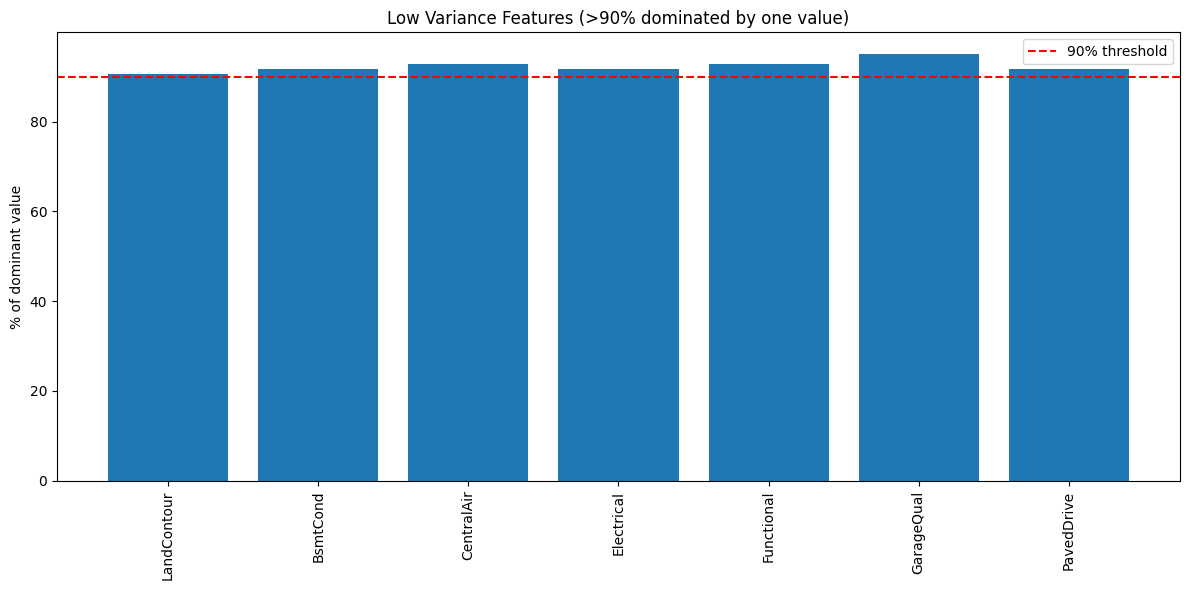

Found 7 low variance columns: ['LandContour', 'BsmtCond', 'CentralAir', 'Electrical', 'Functional', 'GarageQual', 'PavedDrive']


In [66]:
import matplotlib.pyplot as plt

low_var_cols = []
low_var_pcts = []

for col in X_train.columns:
    top_val_pct = X_train[col].value_counts(normalize=True).iloc[0] * 100
    if top_val_pct > 90:
        low_var_cols.append(col)
        low_var_pcts.append(top_val_pct)

plt.figure(figsize=(12, 6))
plt.bar(low_var_cols, low_var_pcts)
plt.axhline(y=90, color='r', linestyle='--', label='90% threshold')
plt.xticks(rotation=90)
plt.ylabel("% of dominant value")
plt.title("Low Variance Features (>90% dominated by one value)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Found {len(low_var_cols)} low variance columns: {low_var_cols}")

In [67]:
cols_to_drop = ['LandContour', 'Electrical', 'GarageQual', 'BsmtCond']

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [68]:
cat_cols = X_train.select_dtypes(include='object').columns
print(cat_cols)

Index(['MSZoning', 'LotShape', 'LotConfig', 'Neighborhood', 'Condition1',
       'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'MasVnrType',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'CentralAir',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'PavedDrive', 'MoSold', 'SaleType', 'SaleCondition'],
      dtype='object')


In [69]:
cols_to_fill_none = [
    'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 
    'GarageType', 'GarageFinish', 'FireplaceQu', 'MasVnrType'
]

for col in cols_to_fill_none:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna("None")
        X_test[col] = X_test[col].fillna("None")

In [70]:
cols_to_fill_mode = ['MSZoning', 'KitchenQual', 'Exterior1st', 'SaleType', 'Functional']

for col in cols_to_fill_mode:
    if col in X_train.columns:
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)

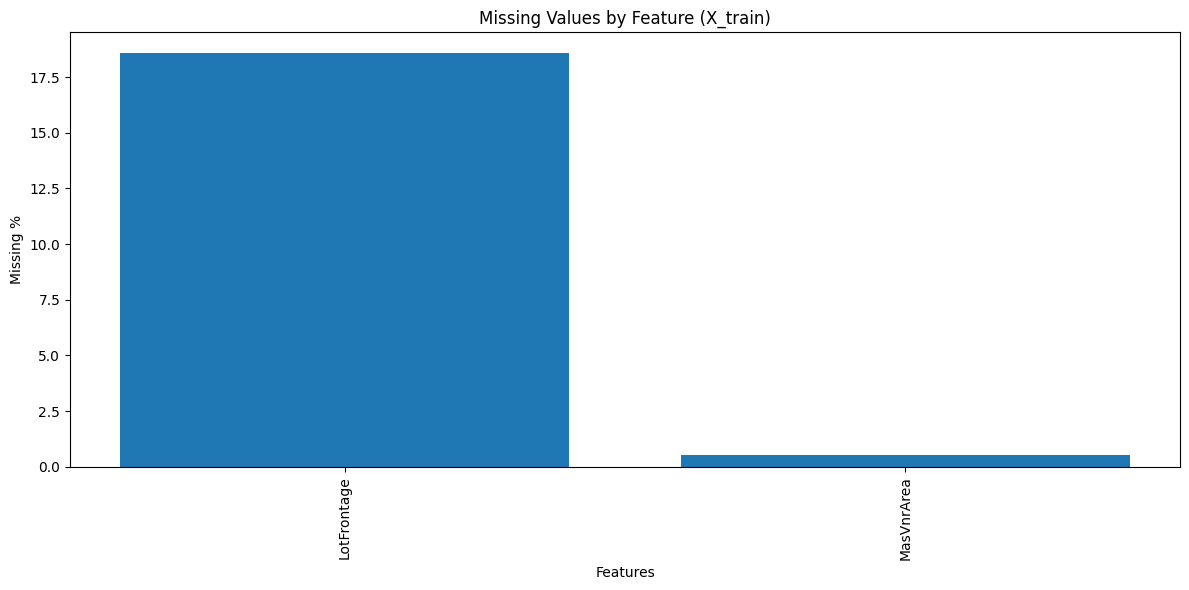

LotFrontage    18.578767
MasVnrArea      0.513699
dtype: float64


In [71]:
import matplotlib.pyplot as plt

null_percent = X_train.isnull().sum() / len(X_train) * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(null_percent.index, null_percent.values)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Missing %")
plt.title("Missing Values by Feature (X_train)")
plt.tight_layout()
plt.show()

print(null_percent)


In [72]:
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(X_train['LotFrontage'].median())
X_test['LotFrontage'] = X_test['LotFrontage'].fillna(X_train['LotFrontage'].median())

In [73]:
X_train.loc[X_train['MasVnrType'] == "None", 'MasVnrArea'] = 0
X_test.loc[X_test['MasVnrType'] == "None", 'MasVnrArea'] = 0

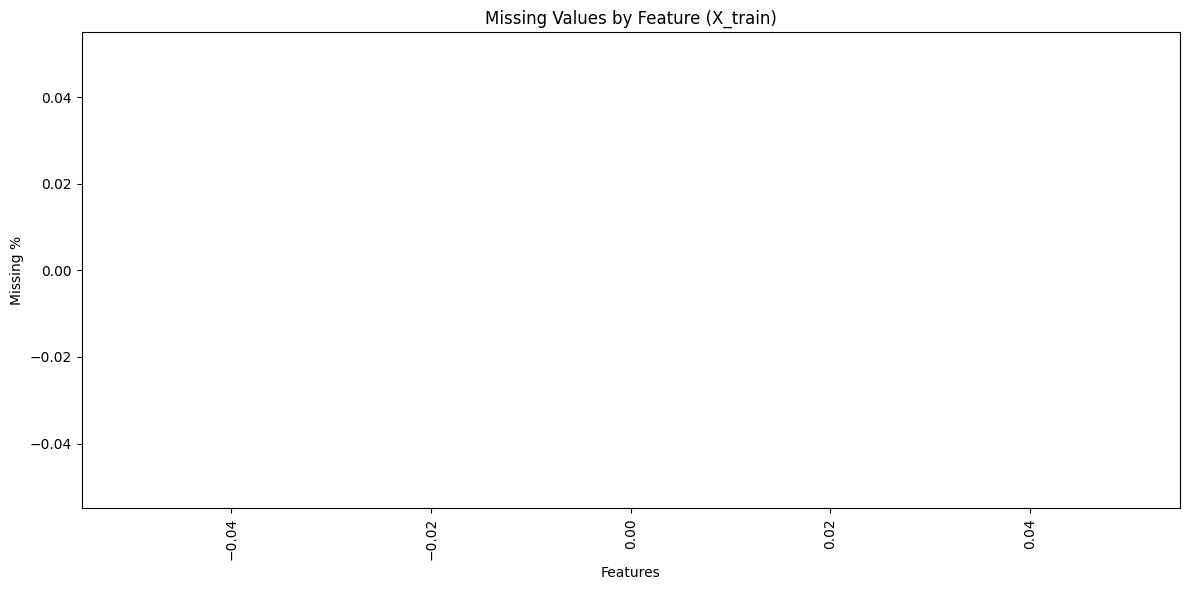

Series([], dtype: float64)


In [74]:
import matplotlib.pyplot as plt

null_percent = X_train.isnull().sum() / len(X_train) * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(null_percent.index, null_percent.values)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Missing %")
plt.title("Missing Values by Feature (X_train)")
plt.tight_layout()
plt.show()

print(null_percent)


In [75]:
total_nulls = X_train.isnull().sum().sum()
print(total_nulls)

0


In [76]:
total_nulls_test = X_test.isnull().sum().sum()
print(total_nulls_test)

0


In [77]:
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'HeatingQC', 'KitchenQual', 'FireplaceQu']

for col in qual_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].map(quality_map)
        X_test[col] = X_test[col].map(quality_map)

X_train['LotShape'] = X_train['LotShape'].map({'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1})
X_test['LotShape'] = X_test['LotShape'].map({'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1})

X_train['GarageFinish'] = X_train['GarageFinish'].map({'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0})
X_test['GarageFinish'] = X_test['GarageFinish'].map({'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0})

In [78]:
cat_cols = X_train.select_dtypes(include='object').columns
print(cat_cols)

Index(['MSZoning', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType',
       'HouseStyle', 'RoofStyle', 'Exterior1st', 'MasVnrType', 'Foundation',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'CentralAir',
       'Functional', 'GarageType', 'PavedDrive', 'MoSold', 'SaleType',
       'SaleCondition'],
      dtype='object')


In [79]:
nominal_cols = [
    'MSZoning', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType',
    'HouseStyle', 'RoofStyle', 'Exterior1st', 'MasVnrType', 'Foundation',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'CentralAir',
    'Functional', 'GarageType', 'PavedDrive', 'MoSold', 'SaleType',
    'SaleCondition'
]

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [80]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Columns: 163 entries, MSSubClass to SaleCondition_Partial
dtypes: bool(133), float64(2), int64(28)
memory usage: 434.6 KB


In [81]:
X_train.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'OverallQual',
       'OverallCond', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=163)

In [82]:
X_train.shape

(1168, 163)

# FEATURE SELECTION

In [83]:
correlations = X_train.corrwith(y_train).abs().sort_values()
low_corr_cols = correlations[correlations < 0.05].index.tolist()
print(low_corr_cols)

['MoSold_3', 'Condition1_RRNe', 'Foundation_Stone', 'Neighborhood_SawyerW', 'Foundation_Wood', 'RoofStyle_Mansard', 'LotConfig_FR2', 'MoSold_2', 'BldgType_TwnhsE', 'Exterior1st_Stucco', 'ExterCond', 'MoSold_8', 'SaleType_ConLw', 'Exterior1st_Plywood', 'MoSold_12', 'Exterior1st_Stone', 'MoSold_10', 'Functional_Mod', 'Functional_Sev', 'BsmtFinType2_GLQ', 'GarageType_Basment', 'Neighborhood_Blueste', 'SaleType_CWD', 'LotConfig_FR3', 'RoofStyle_Shed', 'SaleCondition_Alloca', 'Neighborhood_NWAmes', 'SaleType_Oth', 'Condition1_RRNn', 'Exterior1st_CBlock', 'Condition1_RRAn', 'HouseStyle_2.5Unf', 'Exterior1st_ImStucc', 'RoofStyle_Gambrel', 'Exterior1st_AsphShn', 'MoSold_6', 'MoSold_9', 'SaleType_ConLI', 'MoSold_11', 'MoSold_5', 'SaleType_ConLD', 'MoSold_4', 'BsmtFinType2_Rec', 'Neighborhood_NPkVill', 'BsmtFinType2_LwQ', 'BsmtFinType2_BLQ', 'HouseStyle_SLvl', 'MoSold_7', 'SaleType_Con', 'Neighborhood_Gilbert', 'Condition1_PosA', 'Condition1_RRAe', 'SaleCondition_Family']


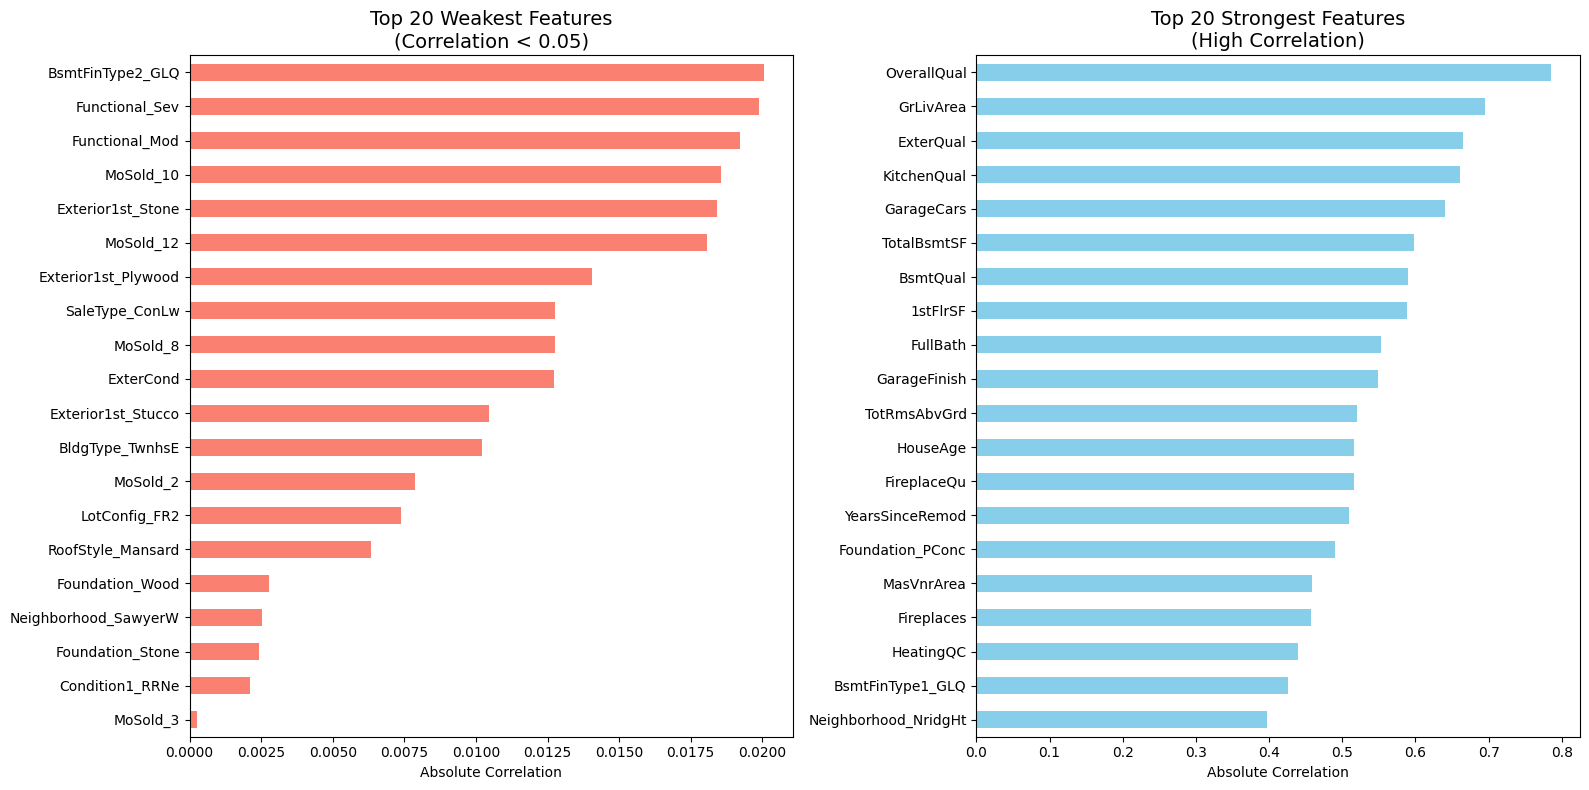

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

all_correlations = X_train.corrwith(y_train).abs().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

all_correlations.head(20).plot(kind='barh', ax=ax1, color='salmon')
ax1.set_title('Top 20 Weakest Features\n(Correlation < 0.05)', fontsize=14)
ax1.set_xlabel('Absolute Correlation')

all_correlations.tail(20).plot(kind='barh', ax=ax2, color='skyblue')
ax2.set_title('Top 20 Strongest Features\n(High Correlation)', fontsize=14)
ax2.set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.show()

In [85]:
X_train = X_train.drop(columns=low_corr_cols)
X_test = X_test.drop(columns=low_corr_cols)

print(f"dropped columns: {cols_to_drop}")
print(f"remaining {X_train.shape[1]} columns in train")
print(f"remaining {X_test.shape[1]} columns in test")

dropped columns: ['LandContour', 'Electrical', 'GarageQual', 'BsmtCond']
remaining 110 columns in train
remaining 110 columns in test


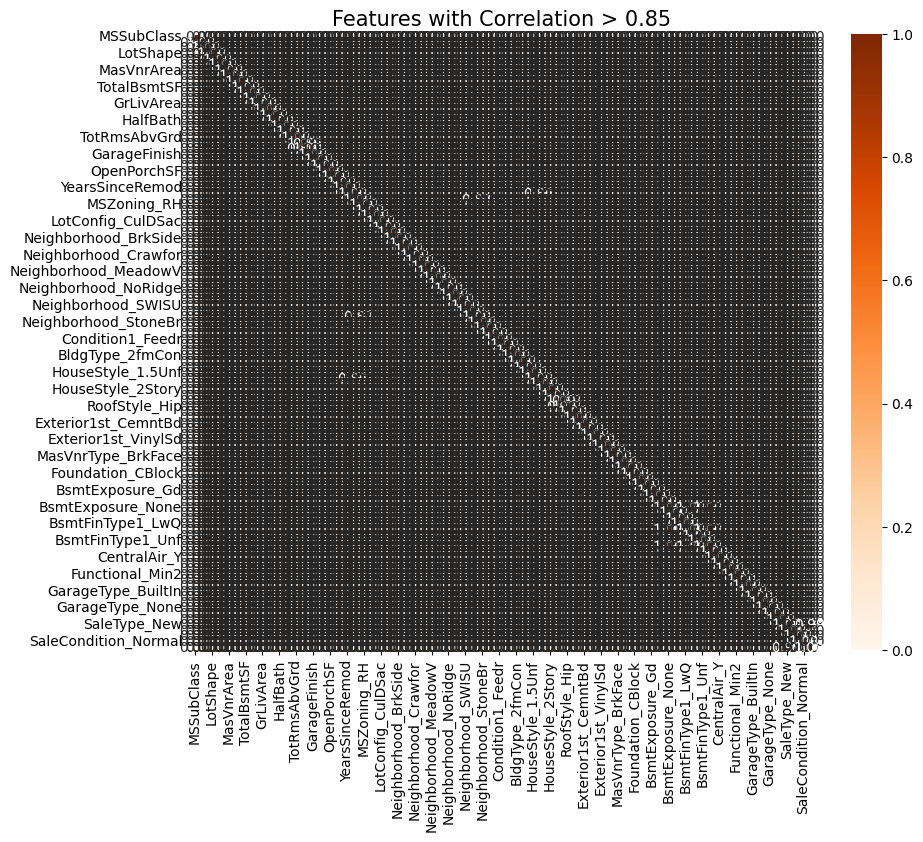

In [86]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_train.corr().abs()

high_corr_var = corr_matrix[corr_matrix > 0.85].fillna(0)
high_corr_var = high_corr_var.loc[(high_corr_var != 0).any(axis=1), (high_corr_var != 0).any(axis=0)]

plt.figure(figsize=(10, 8))
sns.heatmap(high_corr_var, annot=True, cmap='Oranges', fmt=".2f", linewidths=0.5)
plt.title('Features with Correlation > 0.85', fontsize=15)
plt.show()

In [87]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_multi = [column for column in upper.columns if any(upper[column] > 0.85)]

print(f"{to_drop_multi}")

['FireplaceQu', 'Neighborhood_Somerst', 'HouseStyle_1Story', 'RoofStyle_Hip', 'BsmtFinType1_None', 'BsmtFinType2_None', 'SaleCondition_Partial']


In [88]:
to_drop_multi = ['BsmtFinType2_None', 'HouseStyle_1Story', 'RoofStyle_Hip'] 

X_train = X_train.drop(columns=to_drop_multi)
X_test = X_test.drop(columns=to_drop_multi)

In [89]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

selector = RFE(rf, n_features_to_select=45, step=1) 

selector = selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_]

print(f"Selected features: {selected_features.tolist()}")


Selected features: ['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'OverallQual', 'OverallCond', 'MasVnrArea', 'ExterQual', 'BsmtQual', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageFinish', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'HouseAge', 'YearsSinceRemod', 'MSZoning_RL', 'MSZoning_RM', 'LotConfig_CulDSac', 'Neighborhood_NoRidge', 'Condition1_Norm', 'RoofStyle_Gable', 'Exterior1st_MetalSd', 'Exterior1st_Wd Sdng', 'MasVnrType_Stone', 'BsmtExposure_Gd', 'BsmtExposure_No', 'BsmtFinType1_GLQ', 'BsmtFinType1_Unf', 'CentralAir_Y', 'GarageType_Attchd', 'GarageType_Detchd', 'SaleType_New']


In [90]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

X_train_rfe = X_train[selected_features]
X_test_rfe = X_test[selected_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_rfe)
X_test_scaled = scaler.transform(X_test_rfe)

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

lasso_features = X_train_rfe.columns[lasso.coef_ != 0].tolist()
removed_features = X_train_rfe.columns[lasso.coef_ == 0].tolist()

print(f"Lasso left {len(lasso_features)} columns")
print(f"Lasso left: {removed_features}")

Lasso left 34 columns
Lasso left: ['LotShape', 'TotalBsmtSF', 'GarageFinish', 'OpenPorchSF', 'EnclosedPorch', 'YearsSinceRemod', 'MSZoning_RL', 'Exterior1st_MetalSd', 'Exterior1st_Wd Sdng', 'CentralAir_Y', 'GarageType_Attchd']


# TRAINING

In [91]:
import mlflow
import dagshub
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

dagshub.init(repo_owner='tgela23', repo_name='house-prices', mlflow=True)

with mlflow.start_run(run_name="Linear_Regression_Lasso_Features"):
    lr_model = LinearRegression()
    lr_model.fit(X_train[lasso_features], y_train)
    
    y_pred = lr_model.predict(X_test[lasso_features])
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mlflow.log_param("num_features", len(lasso_features))
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("feature_selection", "RFE_then_Lasso")
    
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2_score", r2)
    
    mlflow.sklearn.log_model(lr_model, "linear_model")

In [93]:
from sklearn.tree import DecisionTreeRegressor
import mlflow
from sklearn.metrics import mean_absolute_error, r2_score

depth = 10
min_split = 5
min_leaf = 2

with mlflow.start_run(run_name="DecisionTree_34_Features"):
    dt_model = DecisionTreeRegressor(
        max_depth=depth, 
        min_samples_split=min_split, 
        min_samples_leaf=min_leaf,
        random_state=42
    )
    dt_model.fit(X_train[lasso_features], y_train)
    
    y_pred = dt_model.predict(X_test[lasso_features])
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mlflow.log_param("max_depth", depth)
    mlflow.log_param("min_samples_split", min_split)
    mlflow.log_param("min_samples_leaf", min_leaf)
    mlflow.log_param("model", "DecisionTree")
    
    mlflow.log_metric("mae_mean", mae)
    mlflow.log_metric("r2_mean", r2)
    
    mlflow.sklearn.log_model(dt_model, "decision_tree_model")
    
    print(f"MAE: ${mae:,.2f}")

2026/04/08 09:54:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/08 09:54:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MAE: $24,778.28
🏃 View run DecisionTree_34_Features at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/3d44d859ce014978acdf0e608f9da2d4
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0


In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
import mlflow

param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}

dt = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

with mlflow.start_run(run_name="DecisionTree_GridSearch"):
    grid_search.fit(X_train[lasso_features], y_train)
    
    best_dt = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    y_pred = best_dt.predict(X_test[lasso_features])
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mlflow.log_params(best_params) 
    mlflow.log_metric("mae_mean", mae)
    mlflow.log_metric("r2_mean", r2)
    mlflow.log_param("model_type", "DecisionTree_Optimized")
    
    print(f"Best Parameters: {best_params}")
    print(f"🏠 Best MAE: ${mae:,.2f}")

Best Parameters: {'criterion': 'squared_error', 'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 2}
🏠 Best MAE: $24,157.10
🏃 View run DecisionTree_GridSearch at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/20d4704de1ea4f36bdcf43537bc0d403
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0


In [95]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import mlflow

depths = [3, 5, 10, 15, 20]
min_samples = [2, 10, 20, 50]
criterions = ['squared_error', 'absolute_error']

best_mae = float('inf')
best_params = {}


for d in depths:
    for m in min_samples:
        for c in criterions:
            run_name = f"DT_d{d}_m{m}_{c[:4]}"
            
            with mlflow.start_run(run_name=run_name, nested=True):
                dt = DecisionTreeRegressor(
                    max_depth=d, 
                    min_samples_split=m, 
                    criterion=c, 
                    random_state=42
                )
                dt.fit(X_train[lasso_features], y_train)
                
                y_pred = dt.predict(X_test[lasso_features])
                mae = mean_absolute_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)

                mlflow.log_param("max_depth", d)
                mlflow.log_param("min_samples_split", m)
                mlflow.log_param("criterion", c)
                mlflow.log_metric("mae_mean", mae)
                mlflow.log_metric("r2_mean", r2)

                if mae < best_mae:
                    best_mae = mae
                    best_params = {'depth': d, 'min_samples': m, 'criterion': c, 'r2': r2}

print("\n" + "="*30)
print(f"Best Parameters: {best_params}")
print(f"Minimal MAE: ${best_mae:,.2f}")
print(f"R2: {best_params['r2']:.4f}")
print("="*30)

🏃 View run DT_d3_m2_squa at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/467010ec53144a5da35606691690ef56
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
🏃 View run DT_d3_m2_abso at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/94e2abb20e174bc7b1be0a23599c67d8
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
🏃 View run DT_d3_m10_squa at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/8ff69d227f834c72a36d70bc0b799bc3
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
🏃 View run DT_d3_m10_abso at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/8f9de5f69ddf4405877c54145e1d677e
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
🏃 View run DT_d3_m20_squa at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/819480096d6c4c73a81e94f0a5c41e6

In [96]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import mlflow

estimators = [100, 200, 300]
depths = [10, 15, 20]
features = ['sqrt', 'log2', None] 

best_rf_mae = float('inf')
best_rf_params = {}


for n in estimators:
    for d in depths:
        for f in features:
            run_name = f"RF_n{n}_d{d}_f{f}"
            
            with mlflow.start_run(run_name=run_name, nested=True):
                rf = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=d,
                    max_features=f,
                    random_state=42,
                    n_jobs=-1 
                )
                rf.fit(X_train[lasso_features], y_train)
          
                y_pred = rf.predict(X_test[lasso_features])
                mae = mean_absolute_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
       
                mlflow.log_param("n_estimators", n)
                mlflow.log_param("max_depth", d)
                mlflow.log_param("max_features", f)
                mlflow.log_param("model", "RandomForest")
                
                mlflow.log_metric("mae_mean", mae)
                mlflow.log_metric("r2_mean", r2)
   
                if mae < best_rf_mae:
                    best_rf_mae = mae
                    best_rf_params = {'n_estimators': n, 'depth': d, 'features': f, 'r2': r2}
                
                print(f"Logged: {run_name} -> MAE: ${mae:,.0f}")

print("\n" + "⭐"*15)
print(f"Best Parameters: {best_rf_params}")
print(f"Minimal MAE: ${best_rf_mae:,.2f}")
print(f"R2: {best_rf_params['r2']:.4f}")
print("⭐"*15)

Logged: RF_n100_d10_fsqrt -> MAE: $17,800
🏃 View run RF_n100_d10_fsqrt at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/3ce504e6424c48a0aefaab99f24f51d8
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
Logged: RF_n100_d10_flog2 -> MAE: $17,800
🏃 View run RF_n100_d10_flog2 at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/395a03a4bbf9478face7fdb8ef7c7a1b
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
Logged: RF_n100_d10_fNone -> MAE: $17,800
🏃 View run RF_n100_d10_fNone at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/d4b4903bceab4f13baea5dd62adc6fe8
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
Logged: RF_n100_d15_fsqrt -> MAE: $17,686
🏃 View run RF_n100_d15_fsqrt at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/5df25cac040a48ceaee3313b3d813775
🧪 View experiment at: https://dags

In [97]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import mlflow

learning_rates = [0.01, 0.05, 0.1]
max_depths = [3, 5, 6]
n_estimators = [100, 500, 1000]

best_xgb_mae = float('inf')
best_xgb_params = {}


for lr in learning_rates:
    for d in max_depths:
        for n in n_estimators:
            run_name = f"XGB_lr{lr}_d{d}_n{n}"
            
            with mlflow.start_run(run_name=run_name, nested=True):
                xgb = XGBRegressor(
                    n_estimators=n,
                    max_depth=d,
                    learning_rate=lr,
                    random_state=42,
                    n_jobs=-1
                )
                
                xgb.fit(X_train[lasso_features], y_train)
                
                y_pred = xgb.predict(X_test[lasso_features])
                mae = mean_absolute_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
                
                mlflow.log_param("learning_rate", lr)
                mlflow.log_param("max_depth", d)
                mlflow.log_param("n_estimators", n)
                mlflow.log_param("model", "XGBoost")
                
                mlflow.log_metric("mae_mean", mae)
                mlflow.log_metric("r2_mean", r2)
                
                if mae < best_xgb_mae:
                    best_xgb_mae = mae
                    best_xgb_params = {'lr': lr, 'depth': d, 'n': n, 'r2': r2}
                
                print(f"Logged: {run_name} -> MAE: ${mae:,.0f}")

print("\n" + "👑"*15)
print(f"Best Parameters: {best_xgb_params}")
print(f"Minimal MAE: ${best_xgb_mae:,.2f}")
print(f"R2: {best_xgb_params['r2']:.4f}")
print("👑"*15)

Logged: XGB_lr0.01_d3_n100 -> MAE: $33,386
🏃 View run XGB_lr0.01_d3_n100 at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/8f257ade176a4290ba3d4789930c9384
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
Logged: XGB_lr0.01_d3_n500 -> MAE: $17,863
🏃 View run XGB_lr0.01_d3_n500 at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/6925506bc1294343a51badddf3e879ea
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
Logged: XGB_lr0.01_d3_n1000 -> MAE: $17,084
🏃 View run XGB_lr0.01_d3_n1000 at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/e95037ae3cb84068a64b1ee2e58a2892
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
Logged: XGB_lr0.01_d5_n100 -> MAE: $30,347
🏃 View run XGB_lr0.01_d5_n100 at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/4908c40dafad4afba4b7808616c18656
🧪 View experiment at: ht

# REGISTER BEST MODEL

In [98]:
final_xgb = XGBRegressor(
    learning_rate=0.05, 
    max_depth=5, 
    n_estimators=500, 
    random_state=42
)

final_xgb.fit(X_train[lasso_features], y_train)

with mlflow.start_run(run_name="FINAL_XGB_MODEL"):
    mlflow.log_metric("mae", 16420.60)
    mlflow.log_metric("r2", 0.9116)
    
    mlflow.sklearn.log_model(
        sk_model=final_xgb, 
        artifact_path="model", 
        registered_model_name="HousePrice_XGBoost" 
    )

print("Registered with Name: HousePrice_XGBoost")

2026/04/08 10:40:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/08 10:40:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'HousePrice_XGBoost'.
2026/04/08 10:40:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrice_XGBoost, version 1
Created version '1' of model 'HousePrice_XGBoost'.


🏃 View run FINAL_XGB_MODEL at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0/runs/6bcfb9aee8074ccab1438ca073677a2d
🧪 View experiment at: https://dagshub.com/tgela23/house-prices.mlflow/#/experiments/0
Registered with Name: HousePrice_XGBoost
